In [ ]:
import pandas as pd
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

## Make exported plots' text seen as text in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sns.set_theme(style="white")

palette = {"E/Pcad KO"                              : "#d55e00",
           "EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP" : "#cc78bc",
           "EPcadKO+ER-StayGold+Ecad-GGG-RFP"       : "#56b4e9",
           "E/Pcad KO+Ecad-WT"                      : "#029e73",
           "A431"                                   : "#0173b2",
          }

In [3]:
input_csv_dir = r"C:\Data\ER_Radial_Interpolation_A431_EPcadKO_Ecad-WT\IntensityMeasurements"
output_csv_dir = r"C:\Data\ER_Radial_Interpolation_A431_EPcadKO_Ecad-WT"

output_csv_dir_exists = os.path.exists(output_csv_dir)

if not output_csv_dir_exists:
    os.makedirs(output_csv_dir)

In [4]:
def ProcessDF(df):
    
    # Example filename A431+ER-StayGold_WGA+ER-000_cell-001.tif_C1_Intensity.csv
    
    df[["split1", "split2"]] = df["Label"].str.split(".tif_", expand = True)
    df[["split3", "cell"]] = df["split1"][0].split("_cell-")
    
    df["channel"] = df["split2"].str.slice(start = 1, stop=2)
    df.loc[df["channel"] == "1", "channel_name"] = "ER"
    df.loc[df["channel"] == "2", "channel_name"] = "WGA"
    df.loc[df["channel"] == "3", "channel_name"] = "Ecad"
    df["cell_line"] = df["split3"].str.slice(start = 5, stop = -4)
    df["image"] = df["split3"].str.slice(start=-3)
    df["Rep"] = df["split3"].str.slice(start=3, stop = 4)
    df.drop(columns = ["split1", "split2", "split3"], inplace = True)
    
    
    return df

input_CSVs = os.listdir(input_csv_dir)

df_concat = pd.DataFrame()

for f in input_CSVs:
    f_path = os.path.join(input_csv_dir, f)
    df_temp = pd.read_csv(f_path, usecols = ["Label", "Area", "Mean", "IntDen", "RawIntDen", "Slice"])
    df_temp["Label"] = f
    df_processed = ProcessDF(df_temp)
    df_concat = pd.concat([df_concat, df_processed])

In [5]:
df = df_concat
df

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,181.143,225.071,40769.908,9649682.0,1,001,1,ER,A431+ER-StayGold_WGA+ER,000,1
1,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.109,221.767,2685.347,635585.0,2,001,1,ER,A431+ER-StayGold_WGA+ER,000,1
2,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,11.340,216.965,2460.361,582334.0,3,001,1,ER,A431+ER-StayGold_WGA+ER,000,1
3,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.037,211.729,2548.592,603217.0,4,001,1,ER,A431+ER-StayGold_WGA+ER,000,1
4,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,13.059,207.954,2715.767,642785.0,5,001,1,ER,A431+ER-StayGold_WGA+ER,000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.354,36.964,567.536,134328.0,20,005,2,WGA,EPcadKO+ER-StayGold_WGA+ER,009,3
20,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.894,36.949,587.283,139002.0,21,005,2,WGA,EPcadKO+ER-StayGold_WGA+ER,009,3
21,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.359,36.924,604.053,142971.0,22,005,2,WGA,EPcadKO+ER-StayGold_WGA+ER,009,3
22,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.942,37.237,630.885,149322.0,23,005,2,WGA,EPcadKO+ER-StayGold_WGA+ER,009,3


In [6]:
df["cell_line"].unique()

array(['A431+ER-StayGold_WGA+ER',
       'EPcadKO+ER-StayGold+Ecad-WT-RFP_WGA+ER+Ecad',
       'EPcadKO+ER-StayGold_WGA+ER'], dtype=object)

In [7]:
df["cell_line"] = df["cell_line"].replace({"A431+ER-StayGold_WGA+ER" : "A431",
                                           "EPcadKO+ER-StayGold_WGA+ER" : "E/Pcad KO",
                                           "EPcadKO+ER-StayGold+Ecad-WT-RFP_WGA+ER+Ecad" : "E/Pcad KO+Ecad-WT"
                                          }
                                         )

In [8]:
df_ER = df.loc[df["channel_name"] == "ER"]
df_ER

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,181.143,225.071,40769.908,9649682.0,1,001,1,ER,A431,000,1
1,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.109,221.767,2685.347,635585.0,2,001,1,ER,A431,000,1
2,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,11.340,216.965,2460.361,582334.0,3,001,1,ER,A431,000,1
3,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.037,211.729,2548.592,603217.0,4,001,1,ER,A431,000,1
4,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,13.059,207.954,2715.767,642785.0,5,001,1,ER,A431,000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.354,635.075,9750.717,2307862.0,20,005,1,ER,E/Pcad KO,009,3
20,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.894,565.026,8980.775,2125627.0,21,005,1,ER,E/Pcad KO,009,3
21,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.359,492.101,8050.375,1905414.0,22,005,1,ER,E/Pcad KO,009,3
22,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.942,425.250,7204.690,1705252.0,23,005,1,ER,E/Pcad KO,009,3


In [10]:
mean_list = list()
cell_line_list = list()
cell_list = list()
image_list = list()
rep_list = list()

for key, grp in df_ER.groupby(["cell_line", "cell", "image","Rep"])["Mean"]:
    (cell_line_temp, cell_temp, image_temp, rep_temp) = key
    cell_line_list.append(cell_line_temp)
    cell_list.append(cell_temp)
    image_list.append(image_temp)
    rep_list.append(rep_temp)
    
    
    # The first (index 0) measurement is the nucleus,
    # so we want the second measurement (index 1) 
    mean_list.append(grp / grp.iloc[1])
foo = pd.DataFrame(list(zip(cell_line_list, cell_list, image_list, rep_list, mean_list)),
                  columns = ["cell_line", "cell", "image", "Rep", "Normalized Mean"]
                  )



In [11]:
foo = foo.explode("Normalized Mean", ignore_index=True)
foo

,cell_line,cell,image,Rep,Normalized Mean
0,A431,001,000,1,1.014899
1,A431,001,000,1,1.0
2,A431,001,000,1,0.978347
3,A431,001,000,1,0.954736
4,A431,001,000,1,0.937714
...,...,...,...,...,...
4723,E/Pcad KO+Ecad-WT,004,009,3,0.492283
4724,E/Pcad KO+Ecad-WT,004,009,3,0.447017
4725,E/Pcad KO+Ecad-WT,004,009,3,0.414001
4726,E/Pcad KO+Ecad-WT,004,009,3,0.390135


In [12]:
foo["Slice"] = foo.groupby(["cell_line", "cell", "image", "Rep"]).cumcount()+1
foo

,cell_line,cell,image,Rep,Normalized Mean,Slice
0,A431,001,000,1,1.014899,1
1,A431,001,000,1,1.0,2
2,A431,001,000,1,0.978347,3
3,A431,001,000,1,0.954736,4
4,A431,001,000,1,0.937714,5
...,...,...,...,...,...,...
4723,E/Pcad KO+Ecad-WT,004,009,3,0.492283,20
4724,E/Pcad KO+Ecad-WT,004,009,3,0.447017,21
4725,E/Pcad KO+Ecad-WT,004,009,3,0.414001,22
4726,E/Pcad KO+Ecad-WT,004,009,3,0.390135,23


In [13]:
foo.to_csv(output_csv_dir + "2025-03-28_normalized_ER_rings-to-second-ring.csv", index=False)

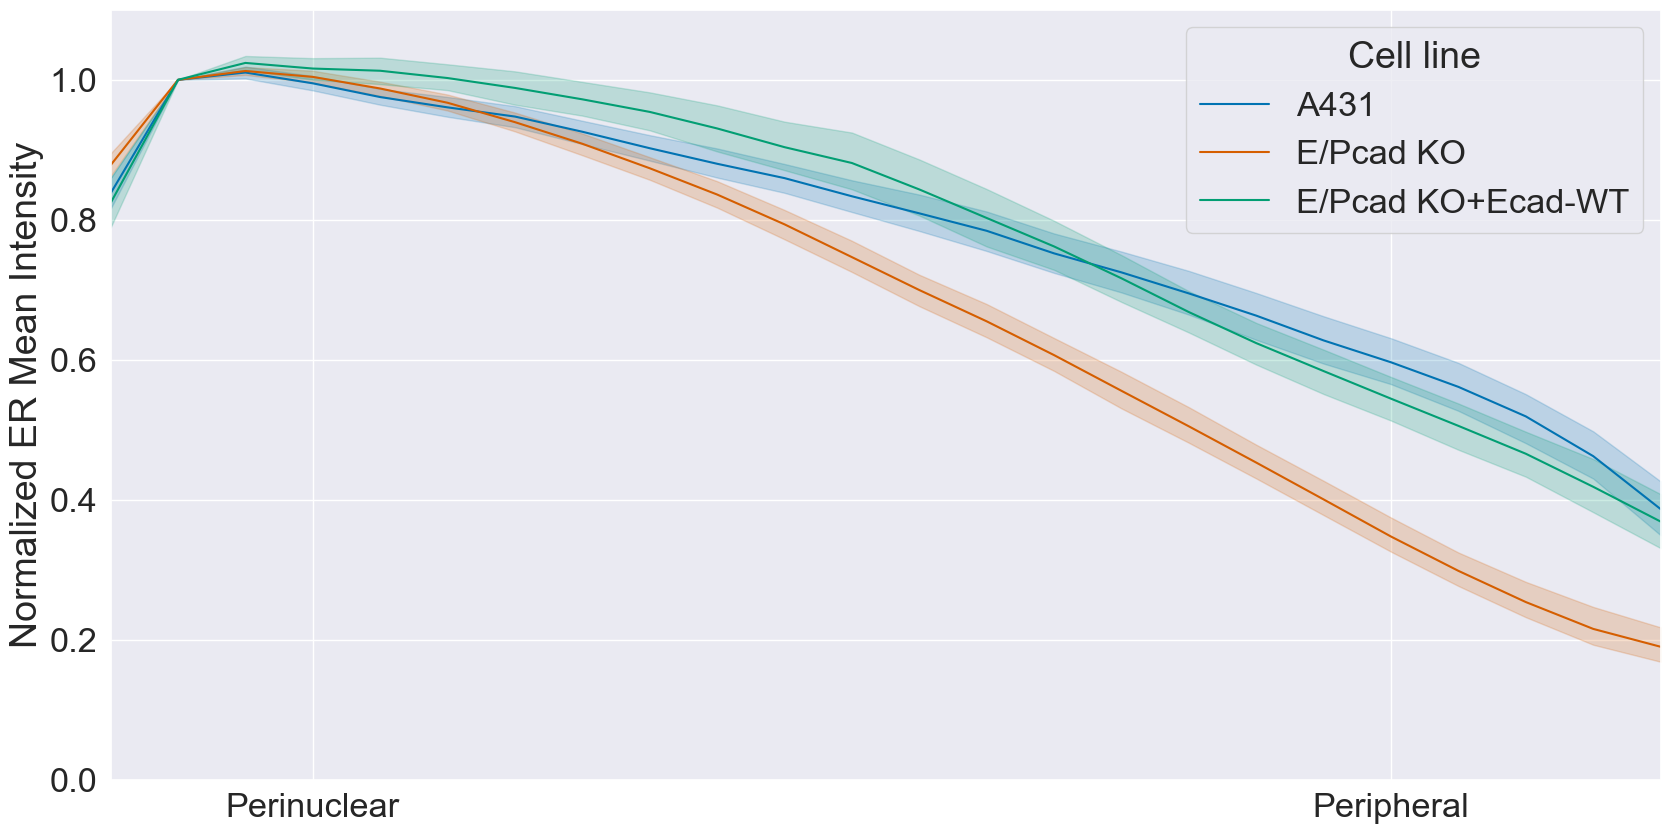

In [ ]:
sns.set_theme(style="white", palette=None)
sns.set(rc = {'figure.figsize':(20,10)})
sns.set(font_scale=2.25)
b = sns.lineplot(data = foo,
                 x = "Slice",
                 y = "Normalized Mean",
                 hue = "cell_line",
                 markers = True,
                 dashes = False,
                 palette=palette,
                )
(b.set(xlim=(-.5, 24),
       xticks=[4, 20],
      )
)
b.set_xticklabels(["Perinuclear", "Peripheral"])
plt.ylabel("Normalized ER Mean Intensity")
plt.xlim(1,24)
plt.ylim(0, 1.1)
plt.xlabel("")

plt.legend(title = "Cell line")
plt.savefig(output_csv_dir + "plot_lines.png", bbox_inches = "tight")
plt.savefig(output_csv_dir + "plot_lines.pdf", bbox_inches = "tight")

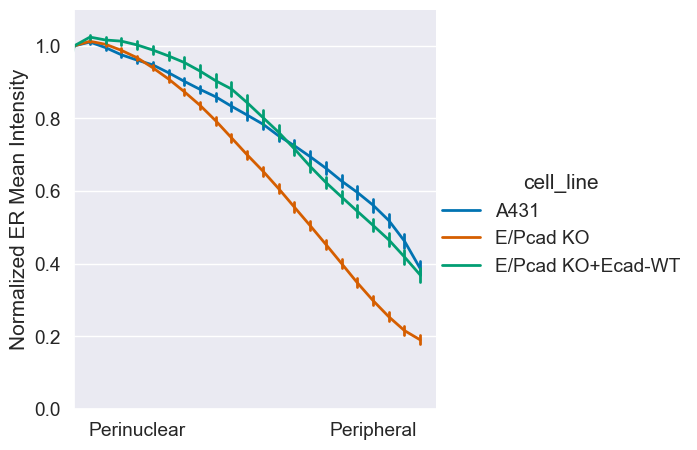

In [ ]:
sns.set_theme(style="white")
sns.set(rc = {'figure.figsize':(20,10)})
sns.set(font_scale=1.25)

c = sns.catplot(
    data = foo,
    x = "Slice",
    y = "Normalized Mean",
    hue = "cell_line",
    errorbar = "se", 
    kind="point",
    fillstyle="none",
    marker=None,
    palette=palette,
    linewidth = 2

)

c.set(xlim=(1, 24), xticks=[5, 20])

c.set_xticklabels(["Perinuclear", "Peripheral"])

plt.ylabel("Normalized ER Mean Intensity")

plt.xlabel("")
plt.xlim(1,24)
plt.ylim(0, 1.1)

plt.savefig(output_csv_dir + "plot_lineplot-with-markers.png", bbox_inches = "tight", dpi= 300)
plt.savefig(output_csv_dir + "plot_lineplot-with-markers.pdf", bbox_inches = "tight", dpi= 300)

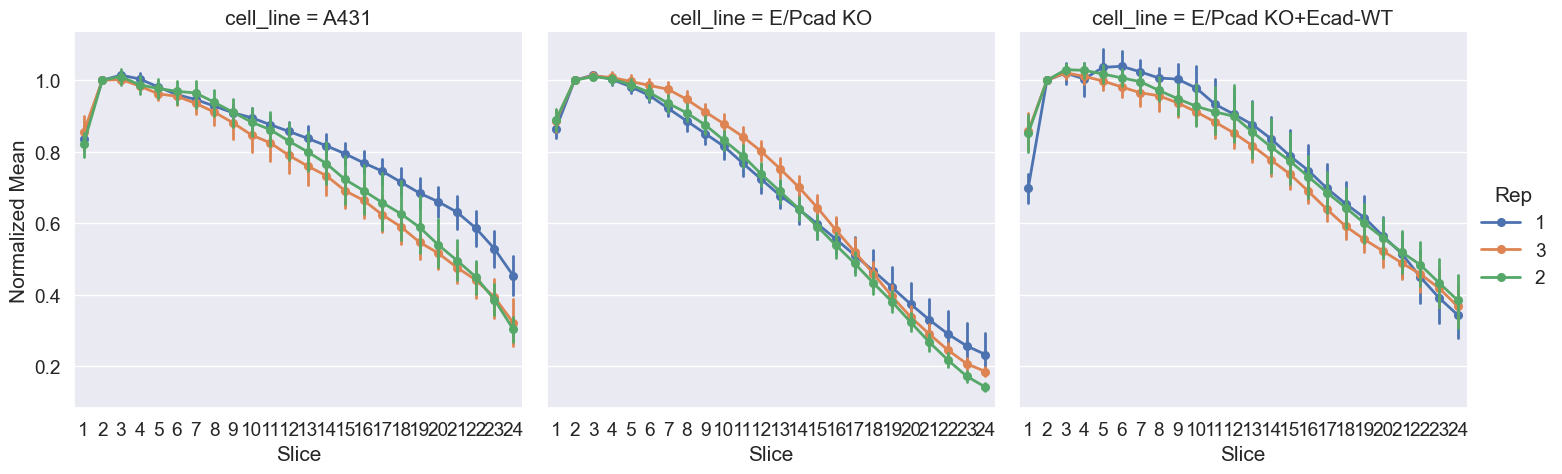

In [16]:
sharp = sns.catplot(foo,
                    x = "Slice",
                    y = "Normalized Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    linewidth = 2
                    #row = "Rep"
                   )

In [19]:
non_nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].tail(23)
non_nuclear_ER_rings

,Mean
1,221.767
2,216.965
3,211.729
4,207.954
5,192.643
...,...
19,635.075
20,565.026
21,492.101
22,425.250


In [20]:
nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].nth(1)
nuclear_ER_rings


,Mean
1,221.767
1,233.616
1,176.411
1,188.365
1,241.106
...,...
1,1368.970
1,1427.287
1,1428.119
1,1925.374


In [21]:
non_nuclear_ER_rings = df_ER.loc[(df_ER["Slice"] > 1)]
non_nuclear_ER_rings

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.109,221.767,2685.347,635585.0,2,001,1,ER,A431,000,1
2,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,11.340,216.965,2460.361,582334.0,3,001,1,ER,A431,000,1
3,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.037,211.729,2548.592,603217.0,4,001,1,ER,A431,000,1
4,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,13.059,207.954,2715.767,642785.0,5,001,1,ER,A431,000,1
5,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,14.589,192.643,2810.462,665198.0,6,001,1,ER,A431,000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.354,635.075,9750.717,2307862.0,20,005,1,ER,E/Pcad KO,009,3
20,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.894,565.026,8980.775,2125627.0,21,005,1,ER,E/Pcad KO,009,3
21,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.359,492.101,8050.375,1905414.0,22,005,1,ER,E/Pcad KO,009,3
22,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.942,425.250,7204.690,1705252.0,23,005,1,ER,E/Pcad KO,009,3


In [24]:
foo = df_ER.loc[(df_ER["Slice"] > 1) & (df_ER["Slice"] < 24)]
foo

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.109,221.767,2685.347,635585.0,2,001,1,ER,A431,000,1
2,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,11.340,216.965,2460.361,582334.0,3,001,1,ER,A431,000,1
3,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,12.037,211.729,2548.592,603217.0,4,001,1,ER,A431,000,1
4,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,13.059,207.954,2715.767,642785.0,5,001,1,ER,A431,000,1
5,Rep1_A431+ER-StayGold_WGA+ER_000_cell-001.tif_...,14.589,192.643,2810.462,665198.0,6,001,1,ER,A431,000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,14.733,717.672,10573.152,2502521.0,19,005,1,ER,E/Pcad KO,009,3
19,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.354,635.075,9750.717,2307862.0,20,005,1,ER,E/Pcad KO,009,3
20,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,15.894,565.026,8980.775,2125627.0,21,005,1,ER,E/Pcad KO,009,3
21,Rep3_EPcadKO+ER-StayGold_WGA+ER_009_cell-005.t...,16.359,492.101,8050.375,1905414.0,22,005,1,ER,E/Pcad KO,009,3


In [25]:
inner = foo[["cell_line", "Mean"]].groupby("cell_line").mean()
inner

,Mean
cell_line,
A431,279.195894
E/Pcad KO,615.187121
E/Pcad KO+Ecad-WT,737.782708


In [27]:
inner_by_rep = foo[["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
inner_by_rep

Mean
cell_line         Rep            
A431              1    183.933459
                  2    386.404805
                  3    381.866869
E/Pcad KO         1    186.267202
                  2    916.971624
                  3    932.971623
E/Pcad KO+Ecad-WT 1    219.802143
                  2    955.447675
                  3    776.353003

In [37]:
outer_by_rep = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
outer_by_rep

Mean
cell_line         Rep            
A431              1     99.333485
                  2    148.520500
                  3    153.356687
E/Pcad KO         1     62.652146
                  2    188.701939
                  3    241.573333
E/Pcad KO+Ecad-WT 1     92.385000
                  2    453.733857
                  3    361.486200

In [36]:
# Outer by cell, image, rep, cell line !!!
outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
outer_by_cell
outer_by_cell.to_csv("outer-by-cell.csv", index=False)

In [ ]:
outer_to_inner_by_rep = outer_by_rep / inner_by_rep
outer_to_inner_by_rep

Mean
cell_line         Rep          
A431              1    0.540051
                  2    0.384365
                  3    0.401597
E/Pcad KO         1    0.336356
                  2    0.205788
                  3    0.258929
E/Pcad KO+Ecad-WT 1    0.420310
                  2    0.474891
                  3    0.465621

In [30]:
perinuclear_by_rep = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
perinuclear_by_rep

Mean
cell_line         Rep             
A431              1     224.194152
                  2     496.784429
                  3     513.721188
E/Pcad KO         1     272.248780
                  2    1370.539121
                  3    1321.231500
E/Pcad KO+Ecad-WT 1     267.944429
                  2    1180.013857
                  3     993.066267

In [35]:
# Perinuclear by cell, image, rep, cell line
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell
perinuclear_by_cell.to_csv("perinuclear-by-cell.csv", index=False)

In [ ]:
outer_to_perinuclear_by_rep = outer_by_rep["Mean"] / perinuclear_by_rep["Mean"]
outer_to_perinuclear_by_rep
#outer_to_perinuclear_by_rep.to_frame().to_csv(output_csv_dir + "/" + "outer-to-perinuclear-by-rep.csv", index=True)

In [34]:

# Outer to perinuclear grouped by cell, image, replicate, cell line

# Extract the relevant data frames
outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]

# Merge on 'cell_line', 'cell', and 'Rep' to align exact replicates
merged_df = pd.merge(outer_by_cell, perinuclear_by_cell, on=["cell_line", "Rep", "image", "cell"], suffixes=("_outer", "_perinuclear"))

# Perform element-wise division of the 'Mean' values
merged_df["Mean_ratio"] = merged_df["Mean_outer"] / merged_df["Mean_perinuclear"]

# Sort the merged DataFrame by 'cell_line' and 'Rep'
merged_df_sorted = merged_df.sort_values(by=["cell_line", "Rep"])

print(merged_df_sorted)
merged_df_sorted.to_csv("ratio-outer-to-perinuclear-by-cell.csv", index=False)

             cell_line Rep image cell  Mean_outer  Mean_perinuclear  \
0                 A431   1   000  001     197.204           221.767   
1                 A431   1   000  002      54.226           233.616   
2                 A431   1   000  003      36.329           176.411   
3                 A431   1   000  004      67.462           188.365   
4                 A431   1   001  001     133.445           241.106   
..                 ...  ..   ...  ...         ...               ...   
168  E/Pcad KO+Ecad-WT   3   009  004     329.051           941.179   
169  E/Pcad KO+Ecad-WT   3   010  001     344.656           975.686   
170  E/Pcad KO+Ecad-WT   3   010  002     423.050          1148.550   
171  E/Pcad KO+Ecad-WT   3   011  001     303.983          1224.676   
172  E/Pcad KO+Ecad-WT   3   012  001     172.326           955.928   

     Mean_ratio  
0      0.889240  
1      0.232116  
2      0.205934  
3      0.358145  
4      0.553470  
..          ...  
168    0.349616  
169

In [ ]:
df.to_csv(output_csv_dir + "" + "2025-04-21_merged-results.csv", index=False)